# **1. AlexNet을 활용한 CIFAR-10 이미지 분류**

- 사용할 AlexNet 모델은 논문에서 나온 원본 AlexNet 모델을 그대로 복제한 모델은 아님
- 원본 AlexNet 모델은 224 * 224 또는 227 * 227 크기의 ImageNet 이미지를 대상으로 설계됐지만 사용할 AlexNet 모델은 32 * 32 크기의 CIFAR-10에 맞게 커널 크기, 스트라이드, 완전 연결층 크기를 조정

### **1. AlexNet의 역사적 의미**
- 2012년 ImageNet 대규모 이미지 분류 대회에서 기본 방식보다 큰 폭으로 오류율을 낮추면서, GPU를 활용한 심층 신경망의 가능성을 널리 알림

### **2. 주요 특징**
- 5개의 합성곱층과 3개의 완전연결층으로 구성
- 기존의 sigmoid나 tanh 대신 ReLU를 적극적으로 사용
- DropOut으로 완전연결층과 과적합 완화
- 이미지 이동, 좌우 반전 등 데이터 증강 사용
- GPU를 활용한 대규모 학습
> 논문에 보고돤 ImageNet 테스트 성능은 Top-1 오류율은 약 37.5%, Top-5 오류율은 약 17.0%

### Top-1과 Top-5 오류율
- Top-1 오류율
    - 모델이 가장 높은 점수를 준 클래스가 정답이 아닌 비율임
    - 예) 실제 정답이 고양이인데, 모델의 1순위 예측이 강아지라면, Top-1 예측은 틀린 것
- Top-5 오류율
    - 모델이 높은 점수를 준 상위 5개 클래스 안에 정답이 포함되지 않는 비율
    - 예) 정답이 고양이이고, 모델의 상위 5개 예측이 다음과 같다고 가정, (강아지, 토끼, 고양이, 호랑이, 여우) > 상위 5개 안에 고양이가 있으므로, Top-5 기준에서는 맞춘 것으로 처리

### CIFAR-10 데이터셋
- 32 * 32 크기의 컬러 이미지 60,000장으로 구성
- 학습용 이미지: 50,000장
- 테스트용 이미지: 10,000장
- 클래스 수: 10개
- 클래스는 비행기, 자동차, 새, 고양이, 사슴, 개, 개구리, 말, 배, 트럭으로 구성

In [1]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from torchvision.transforms.functional import to_pil_image

In [3]:
SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.__version__

'2.13.0+cpu'

In [ ]:
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else: 
    DEVICE = torch.device('cpu')

print(DEVICE)

cpu


In [4]:
DATA_DIR = Path('source')
raw_train_dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=True, # 학습용 데이터만
    download=True,
    transform=transforms.ToTensor()
)

mean = raw_train_dataset.data.mean(axis=(0, 1, 2)) / 255.0 
std = raw_train_dataset.data.std(axis=(0, 1, 2)) / 255.0
# RGB 채널별 평균과 표준편차를 계산하기 위해 axis=(0, 1, 2)를 지정해 계산 후 3개의 값(RGB)에 따른 계산값이 나옴

print(f'평균: {mean}\n표준편차: {std}')

평균: [0.49139968 0.48215841 0.44653091]
표준편차: [0.24703223 0.24348513 0.26158784]


### 정규화가 필요한 이유
- RGB 각 채널의 픽셀값을 평균 0 부근, 적절한 범위로 맞추면 최적화가 더 안정적으로 진행될 수 있음
- 검증 데이터와 테스트 데이터에도 학습 데이터에서 구한 평균과 표준편차를 사용해야 함
- 검증/테스트 데이터 자체에서 통계량을 새로 계산하면 평가 데이터의 정보가 전처리에 반영되는 데이터 누수가 발생할 수 있음

In [5]:
# 훈련용 데이터셋 transform 정의
train_transform = transforms.Compose([
    # 32×32 이미지를 바깥쪽으로 4픽셀 확장한 뒤 다시 32 × 32로 무작위 자르기
    transforms.RandomCrop(32, padding=4),

    # 50% 확률로 좌우 반전
    transforms.RandomHorizontalFlip(),

    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

# 검증용 데이터셋 transform 정의
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

In [6]:
# 학습용 데이터셋과 검증용 데이터셋을 나누는 법 (1)
train_full_dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=False,
    transform=train_transform, # 학습용 transform 적용
)

validation_full_dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=False,
    transform=eval_transform, # 검증용 transform 적용
)

test_dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=eval_transform, # 검증용 transform 적용
)

# 학습용 데이터셋과 검증용 데이터셋을 나누는 법 (2)
all_indices = np.arange(len(raw_train_dataset))
all_targets = np.array(raw_train_dataset.targets)

train_indices, validation_indices = train_test_split(
    all_indices,
    test_size=0.1,
    random_state=SEED,
    stratify=all_targets,
)

train_dataset = Subset(train_full_dataset, train_indices)
validation_dataset = Subset(validation_full_dataset, validation_indices)

print("학습 데이터:", len(train_dataset))
print("검증 데이터:", len(validation_dataset))
print("테스트 데이터:", len(test_dataset))

학습 데이터: 45000
검증 데이터: 5000
테스트 데이터: 10000


In [7]:
BATCH_SIZE = 128
NUM_WORKERS = 0

# Dataloader를 통해 학습 시 데이터를 배치 단위로 불러올 수 있음
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

### 데이터 확인

In [8]:
class_names = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [9]:
def denormalize(image: torch.Tensor, mean, std) -> torch.Tensor:
    mean_tensor = torch.tensor(mean, dtype=image.dtype).view(3, 1, 1)
    std_tensor = torch.tensor(std, dtype=image.dtype).view(3, 1, 1)
    image = image.cpu() * std_tensor + mean_tensor
    return image.clamp(0, 1)

In [10]:
images, labels = next(iter(train_loader))
print(f'Images shape: {images.shape}\nLabels shape: {labels.shape}')

Images shape: torch.Size([128, 3, 32, 32])
Labels shape: torch.Size([128])


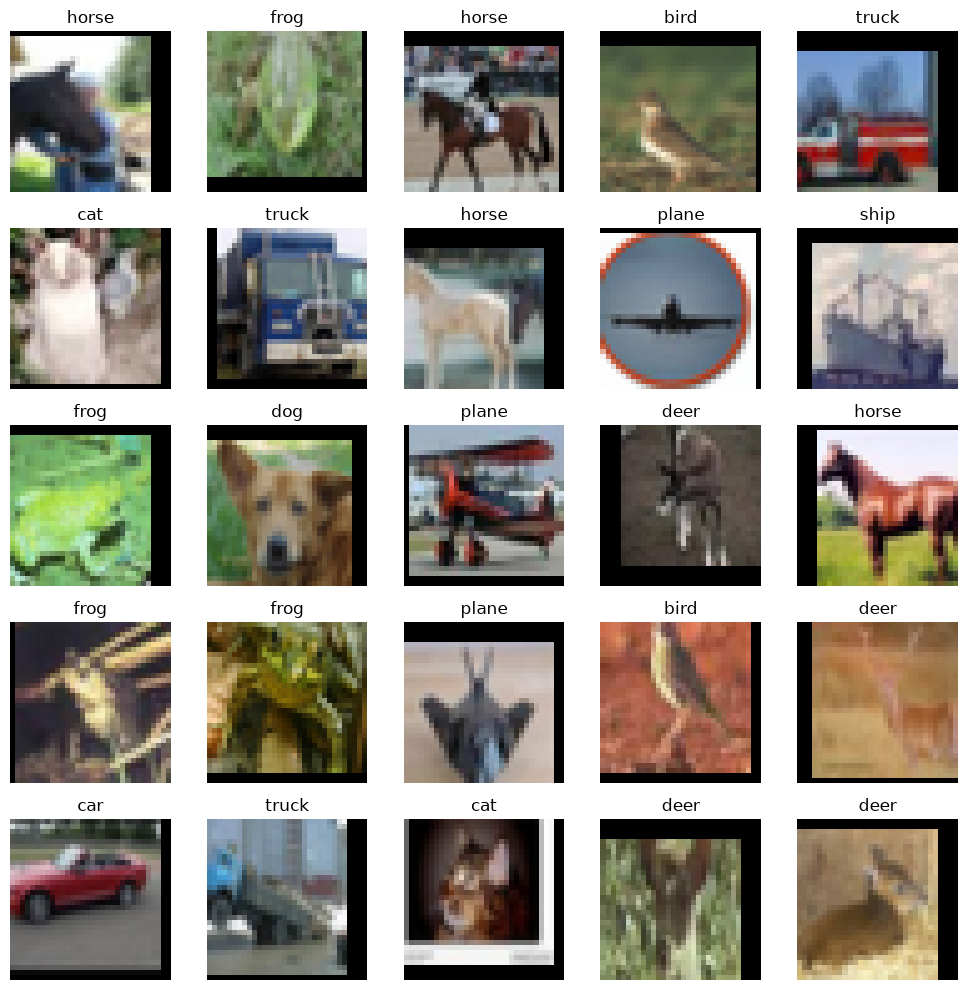

In [11]:
figure = plt.figure(figsize=(10, 10))
rows, cols = 5, 5

for index in range(rows * cols):
    image = denormalize(images[index], mean, std)

    axis = figure.add_subplot(rows, cols, index + 1)
    axis.imshow(to_pil_image(image))
    axis.set_title(class_names[labels[index].item()])
    axis.axis("off")

plt.tight_layout()
plt.show()

In [12]:
class AlexNetCIFAR10(nn.Module):
    def __init__(self, num_classes: int=10):
        super().__init__()
        self.features = nn.Sequential(
            # 입력 (128, 3, 32, 32)
            nn.Conv2d(3, 96, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # 출력 (128, 96, 16, 16)

            nn.Conv2d(96, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # 출력 (128, 256, 8, 8)

            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            # 출력 (128, 384, 8, 8)

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # 출력 (128, 256, 4, 4)
        )
        self.avgpool = nn.AdaptiveAvgPool2d((4, 4)) # 피처 값들의 평균을 계산하여 대표값으로 4 × 4 크기의 피처 맵으로 변환
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(256*4*4, 1024),
            nn.ReLU(inplace=True),

            nn.Dropout(p=0.5),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),

            nn.Linear(512, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, start_dim=1)
        logits = self.classifier(x)
        return logits

### 왜 마지막에 Softmax를 넣지 않을까?
- AlexNet 모델은 일반적으로 nn.CrossEntropyLoss()사용하는데, 이는 내부적으로 LogSoftmax와 NLLLoss를 결합해 계산함(자동으로 Softmax 연산 적용)
- 모델의 마지막 층은 softmax 확률이 아니라 정규화되지 않은 점수인 로짓을 출력해야 함
```
logits = model(image)
loss = criterion(logits, labels)
# 예측 확률을 확인할 때만 아래와 같이 Softmax를 사용
probabilities = torch.softmax(logits, dim=1)
```

In [13]:
model = AlexNetCIFAR10(num_classes=10).to(DEVICE)
print(model)

AlexNetCIFAR10(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(96, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(4, 4))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=4096, out_features=1024, bias=Tr

In [14]:
# parameter.numel(): 텐서 안에 들어 있는 원소의 개수를 구하는 함수
total_parameters = sum(parameter.numel() for parameter in model.parameters())
print(f'전체 파라미터 수: {total_parameters}')

전체 파라미터 수: 8046986


In [15]:
trainable_parameters = sum(
    parameter.numel() for parameter in model.parameters() if parameter.requires_grad # parameter.requires_grad: 학습 가능한 파라미터만 계산
)
print(f'학습 가능한 파라미터 수: {trainable_parameters}')

학습 가능한 파라미터 수: 8046986


In [16]:
# 랜덤한 더미 입력으로 각 단계의 크기 확인
dummy_input = torch.randn(2, 3, 32, 32).to(DEVICE)

# 추론모드 
with torch.inference_mode():
    feature_output = model.features(dummy_input)
    pooled_output = model.avgpool(feature_output)
    logits = model(dummy_input) # 모델 전체를 통과시킨 값

print(f'입력 크기: {dummy_input.shape}')
print(f'합성곱 특징: {feature_output.shape}')
print(f'풀링 이후: {pooled_output.shape}')
print(f'최종 로짓: {logits.shape}')


입력 크기: torch.Size([2, 3, 32, 32])
합성곱 특징: torch.Size([2, 256, 4, 4])
풀링 이후: torch.Size([2, 256, 4, 4])
최종 로짓: torch.Size([2, 10])


### 손실함수와 최적화 방법
- CrossEntrophyLoss: 다중 클래스 분류에서 사용
- AdamW: Adam의 편리한 최적화와 weight decay를 분리해 적용
- ReduceLROnPlateau: 검증 손실이 개선되지 않을 때 학습률 감소
> AdamW가 항상 SGD보다 우수한 것은 아니다. 원본 AlexNet은 momentum을 작용한 SGD를 사용했다. 하지만 이번의 경우 빠르게 실습 결과를 확인하기 위해 AdamW를 사용했다.

In [17]:
EPOCHS = 50
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

### 학습 함수

In [18]:
def train_one_epoch(data_loader, model, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += batch_size

    average_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    return average_loss, accuracy

### 평가 함수

In [19]:
def evaluate(data_loader, model, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.inference_mode():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)
            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_samples += batch_size

    average_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    return average_loss, accuracy

### 학습 및 최고 모델 저장
- 검증 손실이 가장 낮을 때의 가중치만 저장함
- 마지막 에포크의 모델이 항상 가장 좋은 모델은 아님
- 조기 종료는 검증 손실이 여러 에포크 동안 개선되지 않으면 학습을 끝내 과적합과 불필요한 연산을 줄임

In [20]:
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
BEST_MODEL_PATH = OUTPUT_DIR /  'alexnet_cifar10_best.pth'
EARLY_STOPPING_PATIENCE = 5

In [21]:
history = {
    'train_loss': [],
    'train_accuracy': [],
    'validation_loss': [],
    'validation_accuracy': []
}

best_validation_loss = float('inf')
epochs_without_improvement = 0

for epoch in range(1, EPOCHS+1):
    train_loss, train_accuracy = train_one_epoch(
        train_loader, model, criterion, optimizer, DEVICE
    )
    validation_loss, validation_accuracy = evaluate(
        validation_loader, model, criterion, DEVICE
    )
    scheduler.step(validation_loss)

    history['train_loss'].append(train_loss)
    history['train_accuracy'].append(train_accuracy)
    history['validation_loss'].append(validation_loss)
    history['validation_accuracy'].append(validation_accuracy)

    current_lr = optimizer.param_groups[0]["lr"]
    print(f'Epoch [{epoch:02d}/{EPOCHS}]'
        f'lr={current_lr:.6f} | '
        f'train loss={train_loss:.4f}, acc={train_accuracy:.4f} | '
        f'val loss={validation_loss:.4f}, acc={validation_accuracy:.4f}'
    )

    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f'최고 모델 저장: {BEST_MODEL_PATH}')
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print('조기 종료: 검증 손실이 더 이상 개선되지 않았습니다.')
            break

Epoch [01/50]lr=0.001000 | train loss=1.7810, acc=0.3198 | val loss=1.4299, acc=0.4626
최고 모델 저장: outputs\alexnet_cifar10_best.pth
Epoch [02/50]lr=0.001000 | train loss=1.3763, acc=0.4964 | val loss=1.1899, acc=0.5696
최고 모델 저장: outputs\alexnet_cifar10_best.pth
Epoch [03/50]lr=0.001000 | train loss=1.1677, acc=0.5813 | val loss=1.0342, acc=0.6286
최고 모델 저장: outputs\alexnet_cifar10_best.pth
Epoch [04/50]lr=0.001000 | train loss=1.0414, acc=0.6331 | val loss=0.9703, acc=0.6530
최고 모델 저장: outputs\alexnet_cifar10_best.pth
Epoch [05/50]lr=0.001000 | train loss=0.9432, acc=0.6709 | val loss=0.8731, acc=0.6868
최고 모델 저장: outputs\alexnet_cifar10_best.pth
Epoch [06/50]lr=0.001000 | train loss=0.8689, acc=0.6978 | val loss=0.7656, acc=0.7342
최고 모델 저장: outputs\alexnet_cifar10_best.pth
Epoch [07/50]lr=0.001000 | train loss=0.8110, acc=0.7200 | val loss=0.7133, acc=0.7558
최고 모델 저장: outputs\alexnet_cifar10_best.pth


KeyboardInterrupt: 

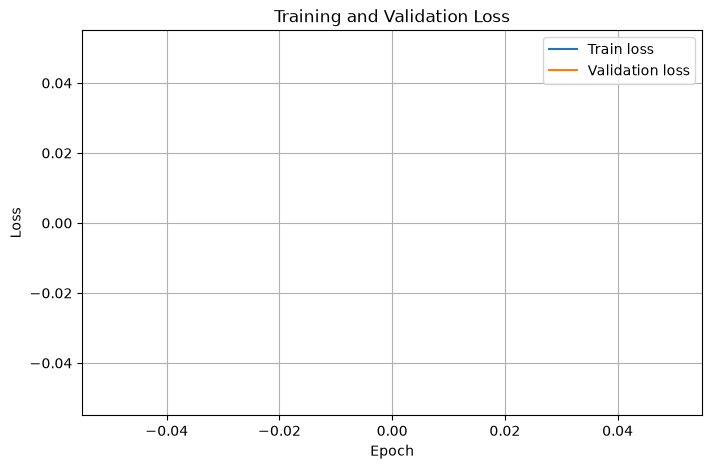

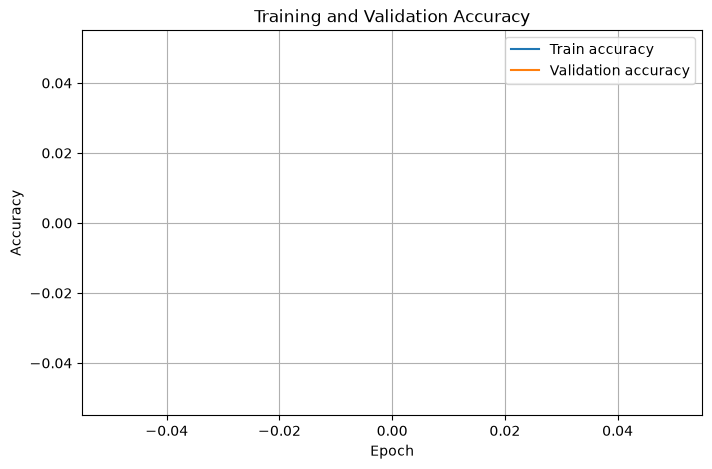

In [ ]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], label="Train loss")
plt.plot(epochs, history["validation_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_accuracy"], label="Train accuracy")
plt.plot(epochs, history["validation_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

# **2. AlexNet 모델 최종 평가**

- 학습과 모델 선택이 모두 끝난 뒤 저장해 둔 최고 모델을 불러옴
- 데스트 데이터는 최종 성능확인에만 사용

In [ ]:
try: # 최신 버전 불러오기
    best_state_dict = torch.load(
        BEST_MODEL_PATH,
        map_location=DEVICE,
        weights_only=True,
    )
except TypeError: # 구 버전 불러오기
    best_state_dict = torch.load(BEST_MODEL_PATH, map_location=DEVICE)

model.load_state_dict(best_state_dict)

test_loss, test_accuracy = evaluate(
    test_loader, model, criterion, DEVICE
)

print(f"테스트 손실: {test_loss:.4f}")
print(f"테스트 정확도: {test_accuracy * 100:.2f}%")

테스트 손실: 0.4970
테스트 정확도: 84.72%


### 혼동행렬과 클래스별 성능

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
def collect_predictions(data_loader, model, device):
    model.eval()
    true_labels = []
    predicted_labels = []

    with torch.inference_mode():
        for images, labels in data_loader:
            images = images.to(device)
            logits = model(images)
            predictions = logits.argmax(dim=1).cpu()
            true_labels.extend(labels.numpy().tolist())
            predicted_labels.extend(predictions.numpy().tolist())

    return np.array(true_labels), np.array(predicted_labels)


true_labels, predicted_labels = collect_predictions(
    test_loader, model, DEVICE
)

confusion = confusion_matrix(true_labels, predicted_labels)
confusion

array([[862,  13,  29,  16,   9,   0,   5,   6,  37,  23],
       [  4, 949,   0,   3,   0,   1,   4,   2,  11,  26],
       [ 40,   1, 748,  47,  47,  39,  45,  24,   5,   4],
       [  7,   5,  31, 702,  48, 116,  38,  29,   9,  15],
       [ 10,   1,  35,  27, 847,  18,  36,  23,   3,   0],
       [  6,   5,  22, 123,  28, 782,  14,  18,   1,   1],
       [  6,   3,  22,  33,  17,  10, 900,   3,   2,   4],
       [ 12,   1,  17,  25,  28,  31,   2, 876,   2,   6],
       [ 44,   9,   7,   4,   3,   1,   6,   1, 910,  15],
       [ 20,  53,   2,   3,   1,   5,   5,   1,  14, 896]])

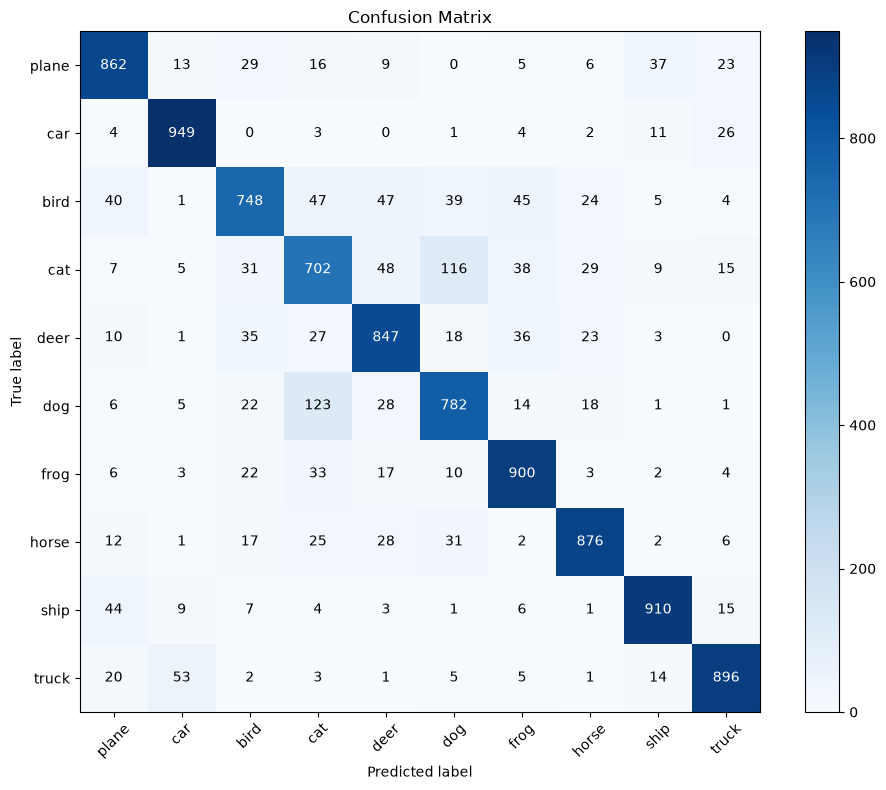

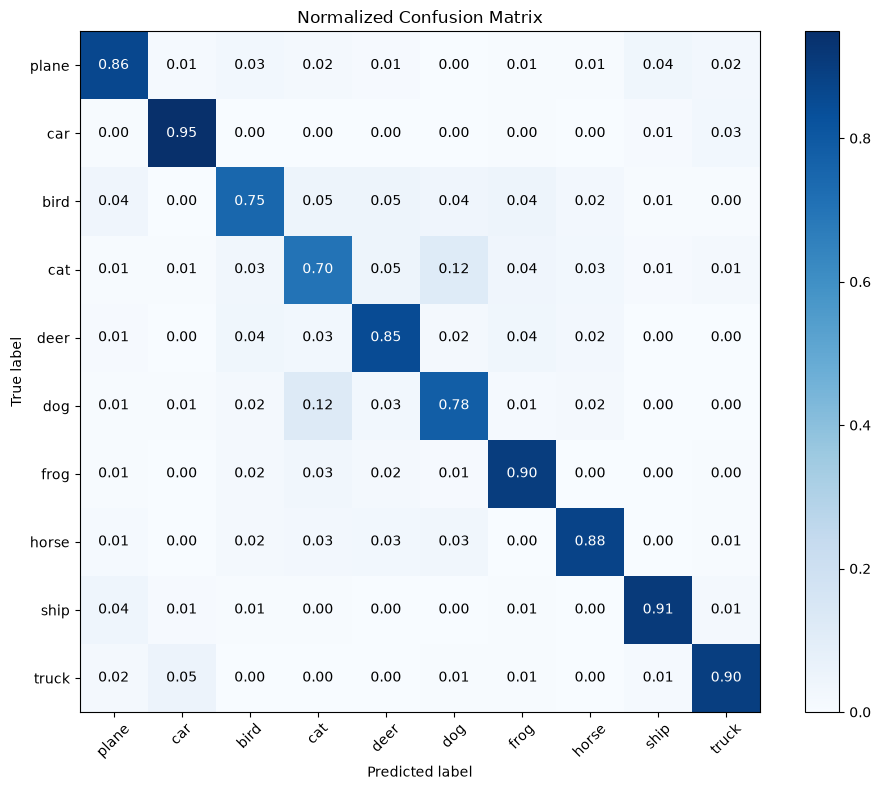

In [ ]:
def plot_confusion_matrix(matrix, class_names, normalize = False,):
    display_matrix = matrix.astype(float)

    if normalize:
        row_sums = display_matrix.sum(axis=1, keepdims=True)
        display_matrix = np.divide(
            display_matrix,
            row_sums,
            out=np.zeros_like(display_matrix),
            where=row_sums != 0,
        )

    plt.figure(figsize=(10, 8))
    plt.imshow(display_matrix, interpolation="nearest", cmap="Blues")
    plt.title("Normalized Confusion Matrix" if normalize else "Confusion Matrix")
    plt.colorbar()

    tick_positions = np.arange(len(class_names))
    plt.xticks(tick_positions, class_names, rotation=45)
    plt.yticks(tick_positions, class_names)

    threshold = display_matrix.max() / 2

    for row in range(display_matrix.shape[0]):
        for column in range(display_matrix.shape[1]):
            value = display_matrix[row, column]
            text = f"{value:.2f}" if normalize else f"{int(value)}"

            plt.text(
                column,
                row,
                text,
                ha="center",
                va="center",
                color="white" if value > threshold else "black",
            )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(confusion, class_names, normalize=False)
plot_confusion_matrix(confusion, class_names, normalize=True)

In [ ]:
print(classification_report(
        true_labels,
        predicted_labels,
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

       plane     0.8526    0.8620    0.8573      1000
         car     0.9125    0.9490    0.9304      1000
        bird     0.8193    0.7480    0.7820      1000
         cat     0.7141    0.7020    0.7080      1000
        deer     0.8239    0.8470    0.8353      1000
         dog     0.7797    0.7820    0.7808      1000
        frog     0.8531    0.9000    0.8759      1000
       horse     0.8911    0.8760    0.8835      1000
        ship     0.9155    0.9100    0.9127      1000
       truck     0.9051    0.8960    0.9005      1000

    accuracy                         0.8472     10000
   macro avg     0.8467    0.8472    0.8467     10000
weighted avg     0.8467    0.8472    0.8467     10000

